In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statannotations.Annotator  import Annotator
from scipy.stats import friedmanchisquare
import scipy.stats as stats
import scikit_posthocs as sp

# Физиологические маркеры восприятия мяса животного и растительного происхождения

В данном файле представлен алгоритм обработки электрофизиологических данных из выпускной квалификационной работы.
Целью работы являлось определение физиолических паттернов, связанных с гедонистическим восприятием мяса животного и растительного происхождения.<br>В качестве регирируемых физиологических показателей были выбраны электромиография (ЭМГ) мимических мышц и частота сердечных сокращений (ЧСС). Также были зарегистрированы субъективные вербальные отчеты участников о приятности продегустрированных продуктов. <br>В эксперименте был задействован семантический прайминг - предъявление тексового стимула на экране монитора перед подачей пищевого образца. Прайминг мог быть верным, конгруэнтным (например, надпись "курица" перед подачей куриного мяса), либо ложным, неконгруэнтным (например, надпись "курица" перед подачей растительного мяса). Данный методический прием был использован для моделирования эффекта надписей на упаковке на восприятие продукта.

## Анализ поведенческих показателей

Данные представляют собой субъективные отчеты участников о том, насколько приятным оказался для них продегустированный образец (куриное мясо либо соевый аналог со вкусом курицы). В ходе эксперимента участникам было необходимо оценить продукты по шкале от +1 до +7, где +1 - "образец очень не понравился", +7 - "образец очень понравился", значение +4 выступало в качестве нейтрального.

In [4]:
behav = pd.read_csv('your_path/behaviour.csv')
behav.head()

,participant,tp_ch,fp_ch,wp_ch,fp_pb,tp_pb,wp_pb
0,1,7,7,7,5,4,3
1,2,5,6,7,3,5,6
2,3,3,3,2,2,2,2
3,4,6,7,6,6,6,6
4,5,6,6,6,5,3,2


Загруженный датафрейм состоит из следующих столбцов: столбец с номерами участников (всего 30 человек) и 6 групп экспериментальных условий. <br>Группы формировались посредством комбинаций пищевого стимула (куриное мясо - ch в названии столбца, либо растительное мясо - pb в названии столбца) с типом текстового прайминга (ложный прайминг, или fp в названии столбца, например, надпись "курица" перед подачей куриного мяса; верный прайминг, или tp, например, надпись "курица" перед подачей куриного мяса; нулевой прайминг, или wp, - отсутствие тексового стимула перед подачей образца).  

Т.к. данные об оценках являются дискретными, а также группы связные (каждый участник пробовал куриное и растительное мясо со всеми вариантами прайминга), проведем **сравнение групповых оценок с помощью непараметрического теста Фридмана:**

In [86]:
columns = behav.columns[1:]
stat, p_value = friedmanchisquare(*[behav[col] for col in columns])

print(f"Статистика хи-квадрат = {stat:.4f}")
print(f"p-value = {p_value:.4f}")

Статистика хи-квадрат = 3.8263
p-value = 0.5747


p-value > 0.05, следовательно, статистически значимых различий между групповыми оценками нет. Куриное мясо и растительный аналог были одинаково приятны для участников, независимо от наличия/отсутствия или типа прайминга.

Построим график для наглядности:

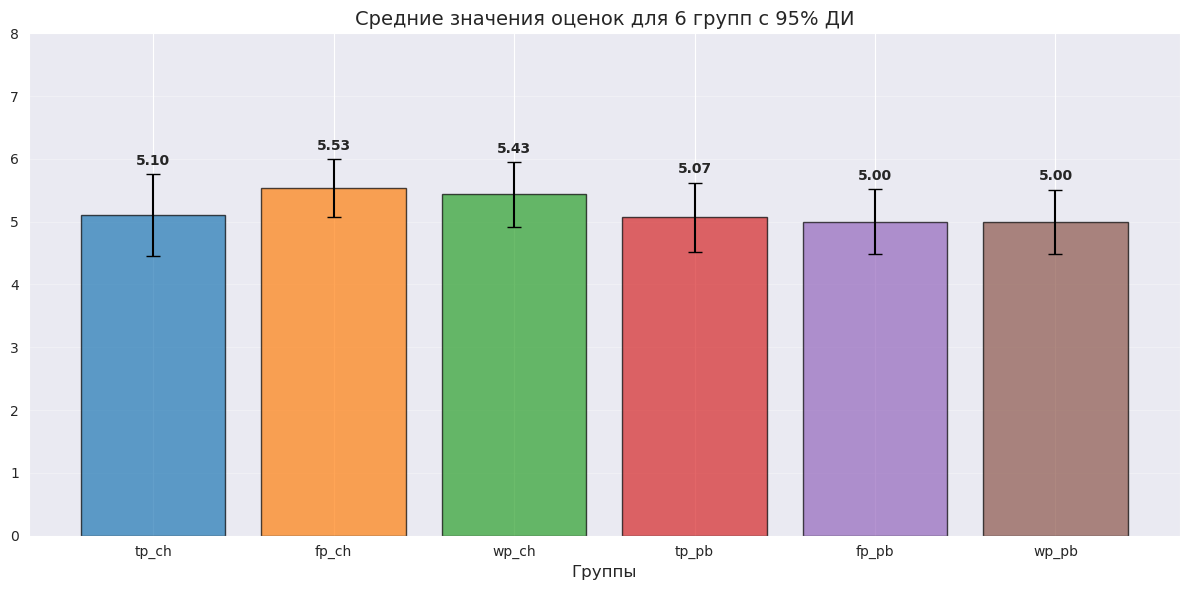

In [93]:
groups = ['tp_ch', 'fp_ch', 'wp_ch', 'tp_pb', 'fp_pb', 'wp_pb']

# расчет средних и стандартных ошибок

means = [behav[g].mean() for g in groups]
errors = [stats.sem(behav[g]) for g in groups]  
ci_errors = [stats.t.interval(0.95, len(behav)-1, loc=behav[g].mean(), 
                               scale=stats.sem(behav[g]))[1] - behav[g].mean() 
             for g in groups]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(groups, means, yerr=ci_errors, capsize=5,
              color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'],
              edgecolor='black', alpha=0.7)


for bar, mean, err in zip(bars, means, ci_errors):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + err + 0.1,
            f'{mean:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Группы', fontsize=12)
ax.set_title('Средние значения оценок для 6 групп с 95% ДИ', fontsize=14)
ax.set_ylim(0, 8)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## Анализ данных ЭМГ

Здесь представлен **анализ средней активации большой скуловой мышцы** (m. Zygomaticus) во время дегустации пищевых образцов для каждой группы. Т.к. активность m. Zygomaticus связана с формированием выражения улыбки на лице, повышенная активация данной мышцы традиционно связывается с субъективно приятным опытом. 

In [5]:
zyg = pd.read_csv('your_path/zygomaticus.csv')
zyg.head()

,participant,tp_ch,fp_ch,wp_ch,fp_pb,tp_pb,wp_pb
0,1,4.320000e-14,5.850000e-13,3.320000e-09,1.450000e-13,3.620000e-12,1.780000e-10
1,2,3.600000e-13,4.920000e-13,5.260000e-13,4.530000e-13,3.490000e-13,3.200000e-13
2,3,2.640000e-13,1.040000e-13,1.090000e-13,1.060000e-13,1.040000e-13,1.050000e-13
3,4,1.450000e-13,1.640000e-13,1.430000e-13,1.310000e-13,1.170000e-13,1.200000e-13
4,5,9.310000e-14,3.350000e-42,1.430000e-13,1.390000e-36,1.390000e-36,1.390000e-36


В связи с форматом данных ЭМГ, а также индивидуальными различиями меджу участниками (за счет вариативности в строении мышцы, а также в креплении электродов), ряд исследователей рекомендует трансформацию "сырых" значений активации в **z-скоры**. $$z = \frac{x - \mu}{\sigma}$$


In [6]:
# проведем z-скорирование по каждому участнику для минимизации вклада индивидуальных различий:

z = zyg.copy()
z[z.columns[1:]] = z[z.columns[1:]].apply(
    lambda row: (row - row.mean()) / row.std(ddof=1), axis=1
)

In [57]:
z[z.columns[1:]].describe()

,tp_ch,fp_ch,wp_ch,fp_pb,tp_pb,wp_pb
count,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
mean,0.297715,-0.017011,0.180276,-0.023363,0.114408,-0.552025
std,1.049786,0.812795,0.739560,1.070323,0.941267,0.622814
min,-1.369049,-1.628959,-0.656867,-1.849689,-1.155694,-1.912190
25%,-0.478036,-0.438932,-0.408248,-0.629127,-0.553658,-0.968974
50%,0.057566,-0.408248,0.011137,-0.408248,-0.408204,-0.441109
75%,0.905808,0.566216,0.545329,0.534890,0.924088,-0.406163
max,2.041241,1.550762,2.038402,2.041241,2.041229,0.973830


Данные переведены в z-скоры, теперь можно переходить к сравнению групп. Для начала необходимо определить, являются ли распределения данных нормальными.

In [89]:
# тест Шапиро-Уилка на каждой группе данных:

for col in z.columns[1:]:
    stat, p = stats.shapiro(z[col])
    print(f"{col}: Shapiro-Wilk W={stat:.3f}, p={p:.4e}")

tp_ch: Shapiro-Wilk W=0.908, p=1.7606e-02
fp_ch: Shapiro-Wilk W=0.889, p=6.3731e-03
wp_ch: Shapiro-Wilk W=0.882, p=4.5295e-03
fp_pb: Shapiro-Wilk W=0.915, p=2.5423e-02
tp_pb: Shapiro-Wilk W=0.898, p=1.0339e-02
wp_pb: Shapiro-Wilk W=0.906, p=1.5582e-02


p-value < 0.05 для каждой группы, соответственно, данные распределены ненормально, необходимо использовать непараметрические тесты.

**Проведем сравнение групп с помощью непараметрического теста Фридмана для связных выборок:**

In [90]:
columns = z.columns[1:]
stat, p_value = friedmanchisquare(*[z[col] for col in columns])

print("\nРезультаты теста Фридмана:")
print(f"Статистика хи-квадрат = {stat:.4f}")
print(f"p-value = {p_value:.4f}")


Результаты теста Фридмана:
Статистика хи-квадрат = 8.0731
p-value = 0.1523


p-value > 0.05, соответственно, статистически значимых различий между группами нет, степень активации m. Zygomaticus одинакова для всех комбинаций условий, что согласуется с поведенческими данными, не обнаружившими различий в степени приятности пищевых стимулов для участников.

Построим график для наглядности:

/tmp/ipykernel_4076/3488769743.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


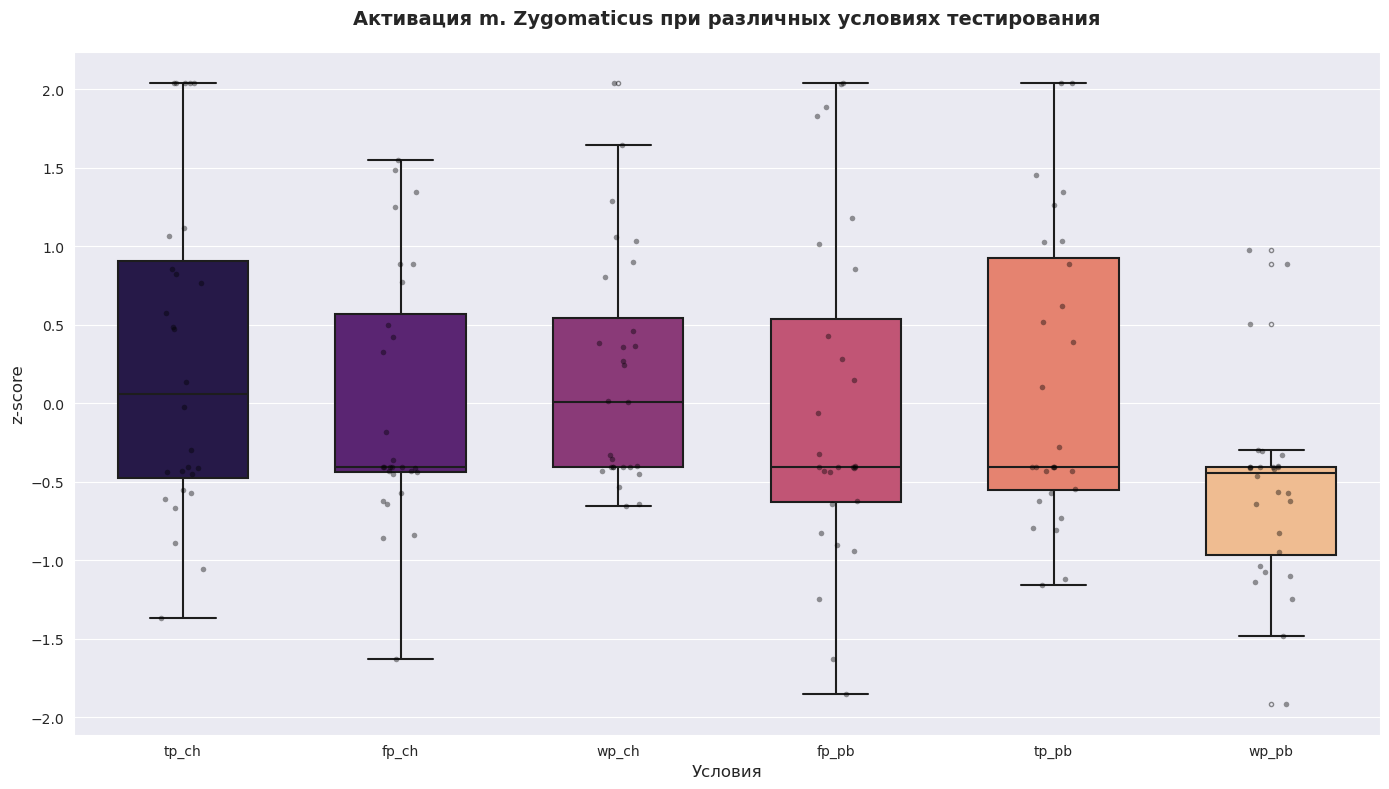

In [91]:
# преобразуем данные в длинный формат:

z_long = pd.melt(
    z,
    id_vars='participant',
    var_name='condition', 
    value_name='z-score'
)


# боксплоты для визуализации групп:

sns.set_style('darkgrid')
plt.figure(figsize=(14, 8))

ax = sns.boxplot(
    data=z_long,
    x='condition',
    y='z-score',
    palette='magma',
    linewidth=1.5,
    width=0.6,              
    fliersize=3,            
    flierprops={'alpha': 0.5}  
)

sns.stripplot(
    data=z_long,
    x='condition',
    y='z-score',
    color='black',
    size=4,
    alpha=0.4,
    ax=ax
)

plt.title('Активация m. Zygomaticus при различных условиях тестирования', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Условия', fontsize=12)
plt.ylabel('z-score', fontsize=12)


plt.tight_layout()
plt.show()

## Анализ данных ЧСС

В данном разделе представлен анализ средних значений частоты сердечных сокращений (в ударах в минуту) у испытуемых во время дегустации образцов.

In [96]:
hr = pd.read_csv('your_path/hr.csv')
hr.rename(columns={'tp_chiken': 'tp_ch', 'fp_ chiken': 'fp_ch', 
                   'wp_ chiken': 'wp_ch'}, inplace=True)
hr.head(2)

,participant,tp_ch,fp_ch,wp_ch,fp_pb,tp_pb,wp_pb
0,1,94.0,86.5,83.1,81.90175,79.48623,78.0
1,3,87.9,103.0,90.1,88.83703,83.46354,82.8


In [72]:
hr[hr.columns[1:]].describe()

,tp_ch,fp_ch,wp_ch,fp_pb,tp_pb,wp_pb
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
mean,82.416083,83.720792,78.042778,77.714253,78.117385,77.419451
std,11.717772,11.458102,9.280303,12.865199,12.384812,12.024777
min,66.000000,68.400000,64.200000,58.461900,52.641700,54.300000
25%,74.651040,76.500000,71.100000,69.976270,70.219330,69.300000
50%,77.600000,81.400000,77.000000,73.993250,78.035530,76.000000
75%,87.900000,89.100000,83.400000,81.367780,82.390200,84.400000
max,107.000000,107.000000,98.500000,113.307600,108.691200,107.000000


Проведем тесты на нормальность данных по группам:

In [73]:
for col in hr.columns[1:]:
    stat, p = stats.shapiro(hr[col])
    print(f"{col}: Shapiro-Wilk W={stat:.3f}, p={p:.4e}")

tp_ch: Shapiro-Wilk W=0.914, p=3.6652e-02
fp_ch: Shapiro-Wilk W=0.893, p=1.2941e-02
wp_ch: Shapiro-Wilk W=0.937, p=1.2414e-01
fp_pb: Shapiro-Wilk W=0.821, p=5.1512e-04
tp_pb: Shapiro-Wilk W=0.913, p=3.5754e-02
wp_pb: Shapiro-Wilk W=0.903, p=2.1794e-02


Данные средних ЧСС для группы "куриное мясо без прайминга" (wp_ch) имеют нормальное распределение, для остальных групп данные распределены ненормально. Соответственно, для сравнения всех групп необходимо использовать непараметрический тест.

**Проведем сравнение групп с помощью непараметрического теста Фридмана для связных выборок:**

In [74]:
columns =  hr.columns[1:]
stat, p_value = friedmanchisquare(*[hr[col] for col in columns])

print("\nРезультаты теста Фридмана:")
print(f"Статистика хи-квадрат = {stat:.4f}")
print(f"p-value = {p_value:.4f}")


Результаты теста Фридмана:
Статистика хи-квадрат = 25.6358
p-value = 0.0001


p-value < 0.05, соответственно, имеются статистически значимые различия между какими-то из групп. Для определения, между какими именно группами существуют различия, необходимо провести пост-хок тест.

**Воспользуемся пост-хок тестом Неменьи:**

In [76]:
# преобразуем данные в длинный формат:

hr_long = pd.melt(
    hr,
    id_vars='participant',
    var_name='condition', 
    value_name='mean_hr'
)

# пост-хок тест Неменьи:

posthoc_res = sp.posthoc_nemenyi_friedman(
    hr_long, 
    y_col='mean_hr',
    group_col='condition',
    block_col='participant',
    block_id_col='participant',
    melted=True
)

posthoc_res.round(4)

,tp_ch,fp_ch,wp_ch,fp_pb,tp_pb,wp_pb
tp_ch,1.0000,0.3190,0.6069,0.4811,0.6809,0.2413
fp_ch,0.3190,1.0000,0.0039,0.0019,0.0059,0.0003
wp_ch,0.6069,0.0039,1.0000,1.0000,1.0000,0.9907
fp_pb,0.4811,0.0019,1.0000,1.0000,0.9997,0.9984
tp_pb,0.6809,0.0059,1.0000,0.9997,1.0000,0.9798
wp_pb,0.2413,0.0003,0.9907,0.9984,0.9798,1.0000


Визуализируем полученные результаты:

In [78]:
# для аннотации последующего графика

significant_pairs = []
p_values_significant = []

conditions = posthoc_res.columns.tolist()
for i in range(len(conditions)):
    for j in range(i+1, len(conditions)):
        p_val = posthoc_res.iloc[i, j]
        if p_val < 0.05:
            pair = (conditions[i], conditions[j])
            significant_pairs.append(pair)
            p_values_significant.append(p_val)
            print(f"Значимая пара: {conditions[i]} vs {conditions[j]}, p = {p_val:.4f}")

Значимая пара: fp_ch vs wp_ch, p = 0.0039
Значимая пара: fp_ch vs fp_pb, p = 0.0019
Значимая пара: fp_ch vs tp_pb, p = 0.0059
Значимая пара: fp_ch vs wp_pb, p = 0.0003


/tmp/ipykernel_4076/2133296491.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

fp_ch vs. wp_ch: Custom statistical test, P_val:3.871e-03
fp_ch vs. fp_pb: Custom statistical test, P_val:1.874e-03
fp_ch vs. tp_pb: Custom statistical test, P_val:5.869e-03
fp_ch vs. wp_pb: Custom statistical test, P_val:3.318e-04


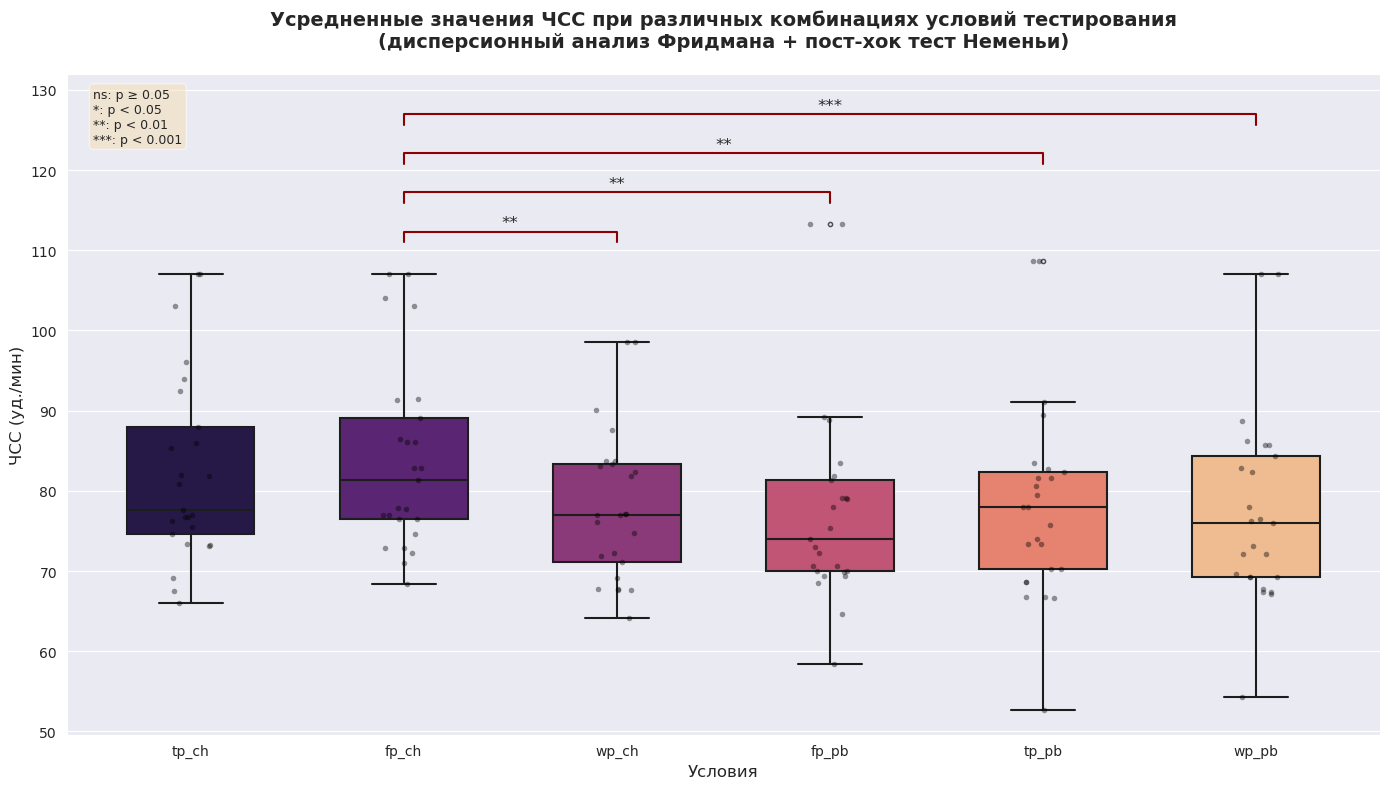

In [84]:
# боксплоты для визуализации групп со статистически значимыми различиями

sns.set_style('darkgrid')
plt.figure(figsize=(14, 8))

ax = sns.boxplot(
    data=hr_long,
    x='condition',
    y='mean_hr',
    palette='magma',
    linewidth=1.5,
    width=0.6,              
    fliersize=3,            
    flierprops={'alpha': 0.5}  
)

sns.stripplot(
    data=hr_long,
    x='condition',
    y='mean_hr',
    color='black',
    size=4,
    alpha=0.4,
    ax=ax
)

plt.title('Усредненные значения ЧСС при различных комбинациях условий тестирования\n(дисперсионный анализ Фридмана + пост-хок тест Неменьи)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Условия', fontsize=12)
plt.ylabel('ЧСС (уд./мин)', fontsize=12)
#plt.xticks(rotation=45, ha='right')

if len(significant_pairs) > 0:
    # словарь для аннотаций в формате, который ожидает statannotations
    annotations_dict = {
        'pairs': significant_pairs,
        'pvalues': p_values_significant
    }

    # создаем аннотатор
    annotator = Annotator(
        ax=ax,
        pairs=significant_pairs,
        data=hr_long,
        x='condition',
        y='mean_hr'
    )

# Настраиваем внешний вид аннотаций
    annotator.configure(
        test=None,                    
        text_format='star',           
        loc='inside',                
        line_height=0.02,            
        line_width=1.5,              
        fontsize=12,                 
        color='darkred'              
    )

    # устанавливаем свои p-values 
    annotator.set_pvalues(p_values_significant)
    
    annotator.annotate()
    
    # добавляем легенду для звездочек
    plt.text(0.02, 0.98, 
             'ns: p ≥ 0.05\n*: p < 0.05\n**: p < 0.01\n***: p < 0.001',
             transform=ax.transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
             fontsize=9)

plt.tight_layout()
plt.show()

Видим, что ЧСС участников значимо выше при комбинации условий "куриное мясо - ложный прайминг". Возможно, это связано с тем, что неконгруэнтный прайминг (текстовый стимул “растительный аналог” перед подачей курицы) создает семантическое несоответствие между текстовой информацией (ожиданием растительного вкуса) и реальными сенсорными ощущениями (вкусом и текстурой курицы). Возможно, при неконгруэнтном прайминге требуется больше когнитивных усилий для интеграции противоречивых сигналов, что отражается в большей потребности головного мозга в притоке кислорода, что приводит, соответственно, к увеличению ЧСС. 